In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree



from mlxtend.frequent_patterns import apriori, association_rules


In [ ]:
# Configuração do estilo dos gráficos do Seaborn para melhor visualização
sns.set(style="whitegrid")

# Função para carregar os dados do Titanic
def carregar_dados():
    df = pd.read_csv("data/train.csv")
    print("Dados carregados com sucesso.")
    return df

# Função para realizar análise exploratória
def analise_exploratoria(df):
    print("\nInformações Gerais:")
    display(df.info())  # Ver tipos de dados, valores não nulos

    print("\nEstatísticas Descritivas:")
    display(df.describe())  # Ver estatísticas como média, desvio padrão etc.

    print("\nValores Nulos:")
    print(df.isnull().sum())  # Identificação de colunas com dados ausentes

    print("\nDistribuição da variável alvo (Survived):")
    sns.countplot(x="Survived", data=df)  # Classe binária: 0 (não sobreviveu), 1 (sobreviveu)
    plt.title("Distribuição de Sobreviventes (0 = Não, 1 = Sim)")
    plt.show()

    print("\nSobrevivência por Sexo:")
    sns.countplot(x="Sex", hue="Survived", data=df)  # Ver relação entre sexo e sobrevivência
    plt.title("Sobrevivência por Sexo")
    plt.show()

    print("\nSobrevivência por Classe:")
    sns.countplot(x="Pclass", hue="Survived", data=df)  # Ver se há relação entre classe social e sobrevivência
    plt.title("Sobrevivência por Classe de Passagem")
    plt.show()

# Função de pré-processamento dos dados
def preprocessamento(df):
    # Preenchimento de valores ausentes com estatísticas apropriadas
    df['Age'].fillna(df['Age'].median(), inplace=True)  # Idade: mediana
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)  # Porto de embarque: moda
    df.drop('Cabin', axis=1, inplace=True)  # Muitos valores ausentes, melhor remover

    # Codificação de variáveis categóricas com get_dummies (evita multicolinearidade com drop_first)
    df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)
    print("🔧 Pré-processamento finalizado. Dados prontos para próxima etapa.")
    return df

# Criação de novas variáveis para enriquecer o modelo
def criar_variaveis(df):
    # Agrupamento de familiares a bordo
    df['Family'] = df['SibSp'] + df['Parch']

    # Extração de título do nome (padrão da cultura da época)
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

    # Padronização de títulos equivalentes
    df['Title'] = df['Title'].replace(['Mlle', 'Ms', 'Mme'], 'Miss')

    # Agrupamento de títulos raros
    df['Title'] = df['Title'].replace(['Capt','Col','Dr','Major','Rev','Jonkheer','Sir','Don'], 'Rare')
    df['Title'] = df['Title'].replace(['Lady','Countess','Dona'], 'Rare')

    print("\nDistribuição dos Títulos:")
    sns.countplot(x='Title', data=df)
    plt.xticks(rotation=45)
    plt.title("Distribuição de Títulos dos Passageiros")
    plt.show()

    # Transformação da variável categórica em variáveis dummy
    df = pd.get_dummies(df, columns=['Title'], drop_first=True)
    return df

# Normalização das variáveis contínuas
def normalizar(df):
    scaler = StandardScaler()  # Usado para trazer os dados para mesma escala
    cols = ['Age', 'Fare']
    if 'Family' in df.columns:
        cols.append('Family')  # Inclui variável derivada 'Family', se existir
    df[cols] = scaler.fit_transform(df[cols])
    print("📏 Dados normalizados com StandardScaler.")
    return df

# Treinamento e avaliação de modelos de classificação
def classificacao(df):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neural_network import MLPClassifier

    # Seleção de features e target
    X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1, errors='ignore')
    y = df['Survived']

    # Divisão em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Menu de escolha de modelos
    print("\n Modelos disponíveis:")
    print("1 - Random Forest")
    print("2 - Árvore de Decisão")
    print("3 - Naive Bayes")
    print("4 - Rede Neural")

    escolha = input("Digite o número do modelo que deseja usar: ")

    # Instancia o modelo com base na escolha do usuário
    if escolha == '1':
        model = RandomForestClassifier(random_state=42)
    elif escolha == '2':
        model = DecisionTreeClassifier(random_state=42)
    elif escolha == '3':
        model = GaussianNB()
    elif escolha == '4':
        model = MLPClassifier(max_iter=500, random_state=42)
    else:
        print(" Modelo inválido.")
        return

    # Treina e avalia
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n Relatório de Classificação:")
    print(classification_report(y_test, y_pred))  # Métricas como precisão, recall, F1

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Não Sobreviveu', 'Sobreviveu'], 
                yticklabels=['Não Sobreviveu', 'Sobreviveu'])
    plt.title("Matriz de Confusão")
    plt.ylabel("Verdadeiro")
    plt.xlabel("Previsto")
    plt.show()

    # Visualização da árvore
    if escolha in ['1', '2']:
        print("\n Visualização da Árvore de Decisão:")
        plt.figure(figsize=(20,10))
        if escolha == '1': 
            # Mostra uma árvore do Random Forest (são várias, mas plota apenas uma)
            plot_tree(model.estimators_[0], feature_names=X.columns, 
                      class_names=['Não Sobreviveu', 'Sobreviveu'], filled=True)
            plt.title("Árvore 1 do Random Forest")
        else:
            # Mostra a árvore inteira se for decisão simples
            plot_tree(model, feature_names=X.columns, 
                      class_names=['Não Sobreviveu', 'Sobreviveu'], filled=True)
            plt.title("Árvore de Decisão")
        plt.show()

# Análise de agrupamento (clustering)
def clusterizacao(df_original):
    df = df_original.copy()

    # Seleção de variáveis para clustering
    X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1, errors='ignore')

    # Redução de dimensionalidade para visualização em 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Agrupamento com KMeans
    kmeans = KMeans(n_clusters=2, random_state=42)
    clusters = kmeans.fit_predict(X)
    centros_pca = pca.transform(kmeans.cluster_centers_)

    df['cluster'] = clusters
    if 'Survived' in df_original.columns:
        df['Survived'] = df_original['Survived']

    # Visualização dos clusters
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='coolwarm', alpha=0.8)
    plt.scatter(centros_pca[:, 0], centros_pca[:, 1], c='black', marker='X', s=200, label='Centros')
    plt.title("Clusters de Passageiros com K-Means + PCA")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Perfil médio de cada cluster
    print("\nPerfil médio de cada cluster:")
    print(df.groupby('cluster').mean(numeric_only=True))

    # Ver taxa de sobrevivência dentro de cada cluster
    if 'Survived' in df.columns:
        print("\nTaxa de sobrevivência por cluster:")
        print(df.groupby('cluster')['Survived'].value_counts(normalize=True).unstack().round(2))

# Regras de associação com Apriori
def regras_associacao():
    assoc_df = pd.read_csv("data/train.csv")

    # Transformação de variáveis em binárias para usar Apriori
    assoc_df['Sex'] = assoc_df['Sex'].map({'male': 0, 'female': 1})
    assoc_df['HighClass'] = assoc_df['Pclass'] == 1
    assoc_df['Family'] = (assoc_df['SibSp'] + assoc_df['Parch']) > 0

    # Manter apenas variáveis categóricas
    assoc_df = assoc_df[['Sex', 'Survived', 'HighClass', 'Family']].astype(int)
    assoc_df = pd.get_dummies(assoc_df)

    # Algoritmo Apriori para gerar itemsets frequentes
    frequent = apriori(assoc_df, min_support=0.1, use_colnames=True)
    rules = association_rules(frequent, metric="lift", min_threshold=1)

    # Seleção das regras mais interessantes
    top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head(5)

    print("\nRegras de Associação:")
    display(top_rules)

    # Interpretação  das regras
    print("\nInterpretação:")
    for _, row in top_rules.iterrows():
        ant = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        print(f"Se {ant} então {cons} (Confiança: {row['confidence']:.2f}, Lift: {row['lift']:.2f})")


<>:54: DeprecationWarning: invalid escape sequence '\.'
<>:54: DeprecationWarning: invalid escape sequence '\.'
/tmp/ipykernel_22666/2031956471.py:54: DeprecationWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Dados carregados com sucesso.



Informações Gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None


Estatísticas Descritivas:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Valores Nulos:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Distribuição da variável alvo (Survived):


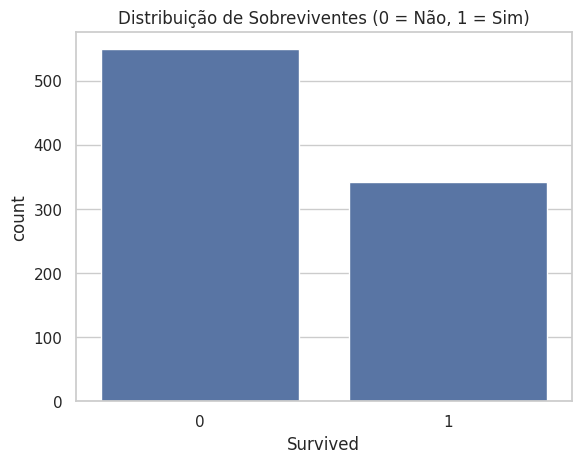


Sobrevivência por Sexo:


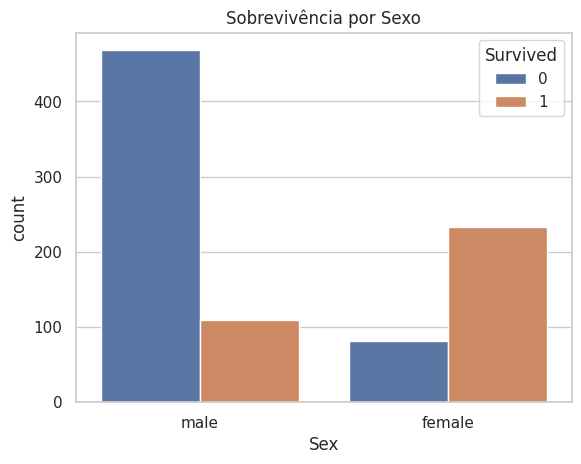


Sobrevivência por Classe:


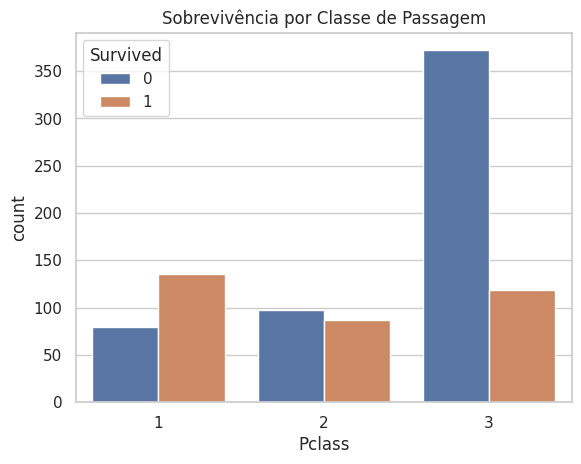

/tmp/ipykernel_22666/2031956471.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)  # Idade: mediana
/tmp/ipykernel_22666/2031956471.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

🔧 Pré-processamento finalizado. Dados prontos para próxima etapa.

Distribuição dos Títulos:


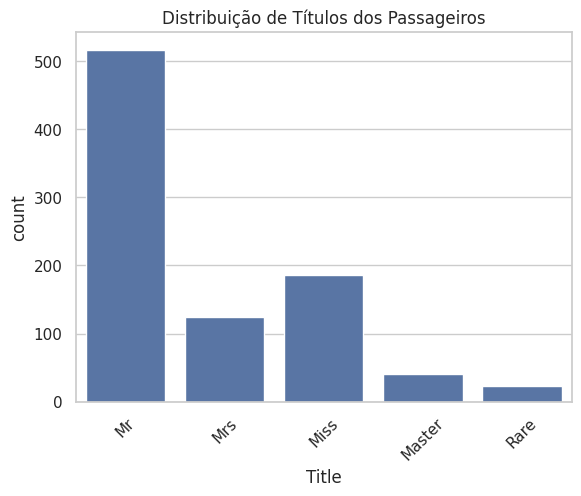

📏 Dados normalizados com StandardScaler.

 Modelos disponíveis:
1 - Random Forest
2 - Árvore de Decisão
3 - Naive Bayes
4 - Rede Neural

 Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       105
           1       0.75      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



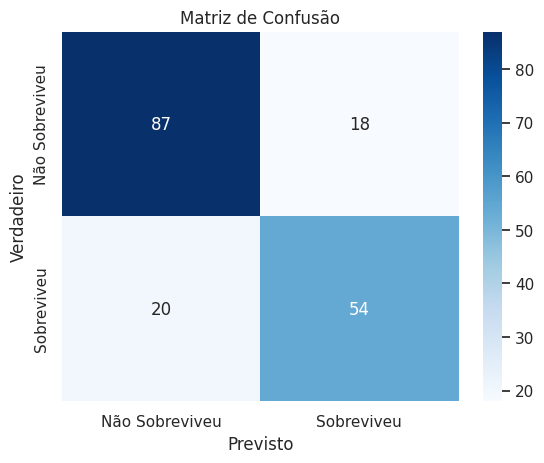


 Visualização da Árvore de Decisão:


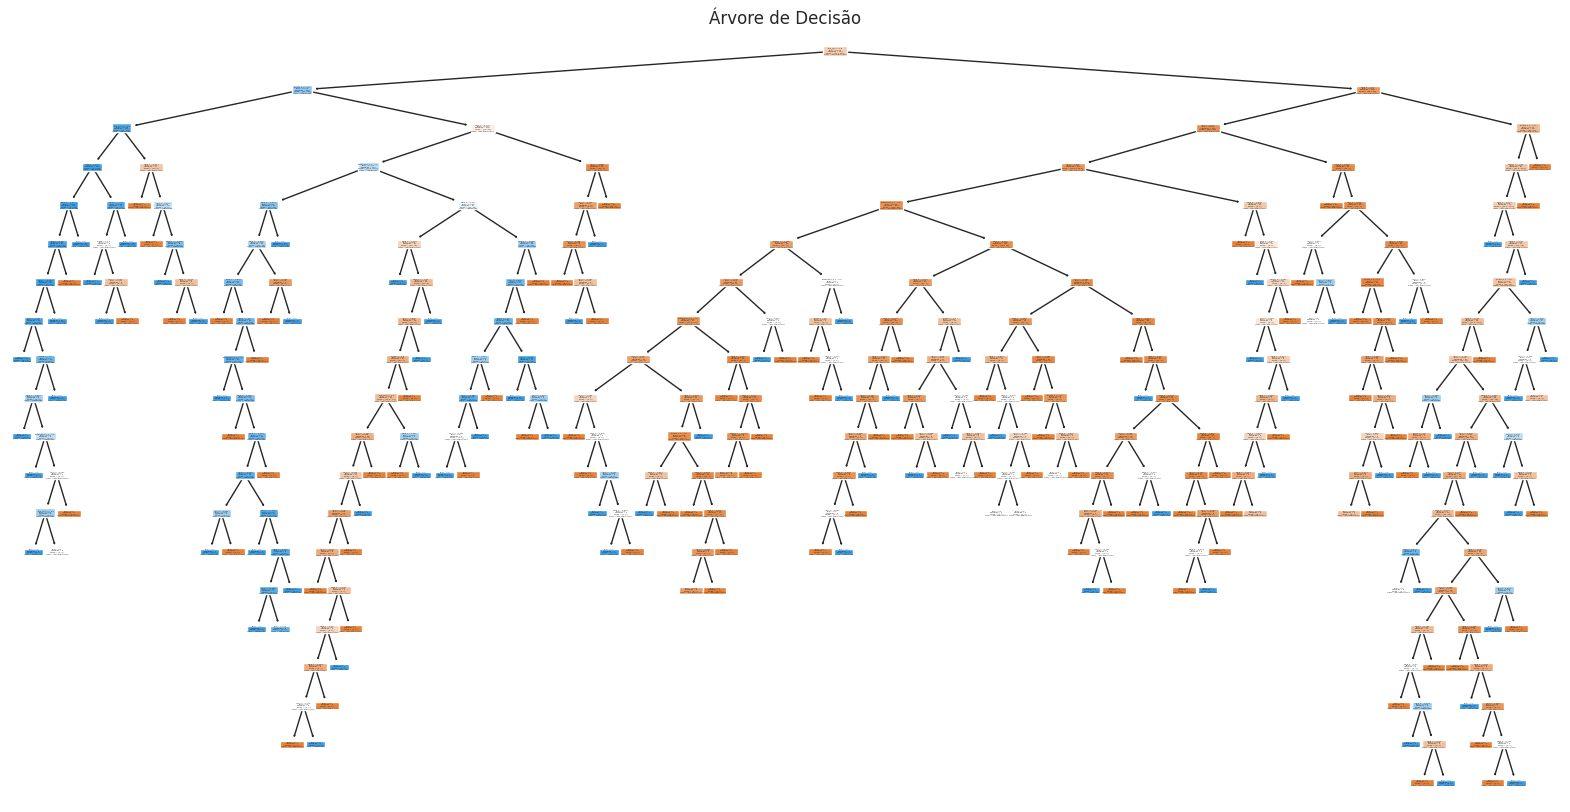

/home/gabriel/gabriel/IA-PUC/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


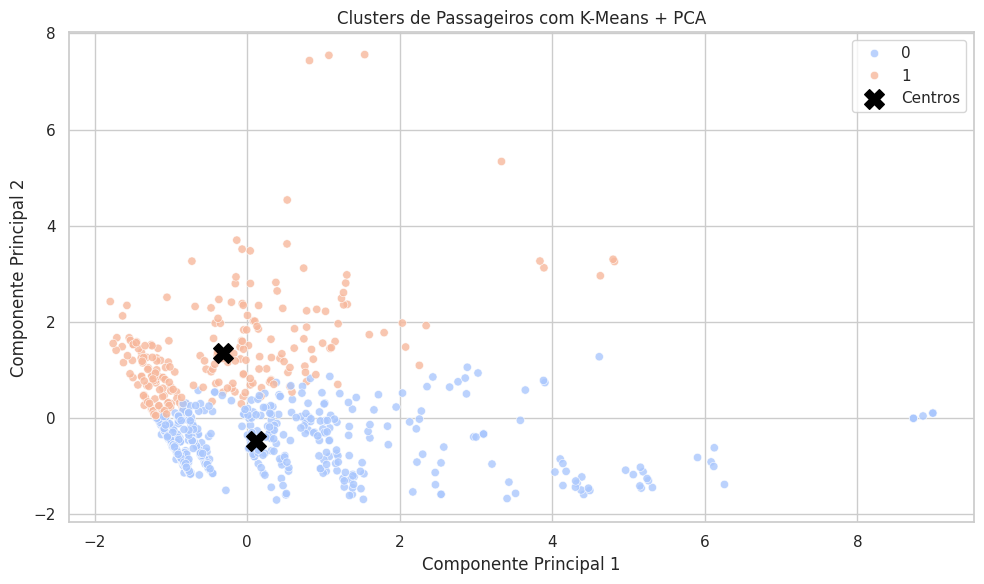


Perfil médio de cada cluster:
         PassengerId  Survived       Age     SibSp     Parch      Fare  \
cluster                                                                  
0         442.840735  0.335375 -0.410605  0.577335  0.408882 -0.260469   
1         454.668067  0.516807  1.126575  0.373950  0.306723  0.714647   

         Sex_male  Embarked_Q  Embarked_S  Pclass_2  Pclass_3    Family  \
cluster                                                                   
0        0.675345    0.110260    0.735069  0.202144  0.701378  0.050613   
1        0.571429    0.021008    0.697479  0.218487  0.138655 -0.138866   

         Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
cluster                                               
0          0.222052  0.607963   0.102603    0.006126  
1          0.172269  0.504202   0.243697    0.079832  

Taxa de sobrevivência por cluster:
Survived     0     1
cluster             
0         0.66  0.34
1         0.48  0.52

Regras de Associação:


/home/gabriel/gabriel/IA-PUC/venv/lib/python3.10/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,support,confidence,lift
16,(Survived),"(HighClass, Sex)",0.102132,0.266082,2.522116
13,"(HighClass, Sex)",(Survived),0.102132,0.968085,2.522116
23,(Sex),"(Family, Survived)",0.150393,0.426752,2.124222
18,"(Family, Survived)",(Sex),0.150393,0.748603,2.124222
1,(Sex),(Survived),0.261504,0.742038,1.933205



Interpretação:
Se Survived então HighClass, Sex (Confiança: 0.27, Lift: 2.52)
Se HighClass, Sex então Survived (Confiança: 0.97, Lift: 2.52)
Se Sex então Family, Survived (Confiança: 0.43, Lift: 2.12)
Se Family, Survived então Sex (Confiança: 0.75, Lift: 2.12)
Se Sex então Survived (Confiança: 0.74, Lift: 1.93)

 Pipeline finalizado.


In [93]:
def main():
    df = carregar_dados()

    if input("Executar análise exploratória? (s/n): ").lower() == 's':
        analise_exploratoria(df)

    if input("Executar pré-processamento? (s/n): ").lower() == 's':
        df = preprocessamento(df)

    if input("Criar variáveis derivadas? (s/n): ").lower() == 's':
        df = criar_variaveis(df)

    if input("Aplicar normalização? (s/n): ").lower() == 's':
        df = normalizar(df)

    if input("Executar classificação? (s/n): ").lower() == 's':
        classificacao(df)

    if input("Executar clusterização? (s/n): ").lower() == 's':
        clusterizacao(df)

    if input("Executar regras de associação? (s/n): ").lower() == 's':
        regras_associacao()

    print("\n Pipeline finalizado.")

main()
